# Refuerzo 1 · K-means: una partición por centros
**60 minutos de trabajo autónomo.** Derive el objetivo, ejecute dos iteraciones manuales y compare
inercia con silhouette. Este método asigna todos los puntos, incluso ubicaciones aisladas.

In [1]:
from pathlib import Path
import sys, time, json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
from threadpoolctl import threadpool_limits

# Funciona desde la raíz, desde esta carpeta o desde docente/.
ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents]
            if (p / 'datasets/semana-08').is_dir())
sys.path.insert(0, str(ROOT / 'notebooks/semana-08'))
from movilidad import (load_data, setup, savefig, save_table, spatial_axes,
                       ellipses, safe_silhouette, density_grid, COLORS, DATA)
setup()
threadpool_limits(limits=2)
frame = load_data()
X = frame[['x_km', 'y_km']].to_numpy()
print(f'Desarrollo: {len(frame):,} recogidas. Unidades: km. Semilla: 42.')
print('Test temporal cerrado hasta congelar el modelo.')
display(frame.head(3))

Desarrollo: 6,000 recogidas. Unidades: km. Semilla: 42.
Test temporal cerrado hasta congelar el modelo.


,source_row,pickup_datetime,pickup_longitude,pickup_latitude,x_km,y_km,fare_amount,passenger_count,dropoff_longitude,dropoff_latitude
0,32038,2014-01-01 00:01:00+00:00,-73.991493,40.735202,0.156182,-0.148260,5.5,5,-74.001727,40.727767
1,132584,2014-01-01 00:29:37+00:00,-74.008090,40.740434,-1.251817,0.416562,8.0,2,-73.996088,40.726627
2,190530,2014-01-01 00:54:07+00:00,-73.981944,40.778096,0.907251,4.622599,7.5,1,-73.967887,40.801430


## Media como minimizador
$$J=\sum_{k=1}^K\sum_{i:z_i=k}\|x_i-\mu_k\|^2.$$
Con asignaciones fijas, $\nabla_{\mu_k}J=2n_k\mu_k-2\sum_{i:z_i=k}x_i=0$.
Por tanto, $\mu_k$ es la media del grupo. Lloyd alterna asignación al centro más cercano y actualización.
Cada paso no aumenta J; el resultado depende de la inicialización. Un grupo vacío requiere una política de reinicio.

### Para resolver

Datos 0, 1, 4, 5 y centros iniciales 0 y 4. Ejecute asignación y actualización. Calcule la inercia final.

**Mi respuesta y evidencia:**

_Escriba aquí su razonamiento; incluya unidades y una limitación._

D:\Documentos\Universidad Externado\Pregrado en Ciencia de Datos\Machine Learning 2\.venv-week4\Lib\site-packages\joblib\externals\loky\backend\context.py:131: UserWarning: Could not find the number of physical cores for the following reason:
found 0 physical cores < 1
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "D:\Documentos\Universidad Externado\Pregrado en Ciencia de Datos\Machine Learning 2\.venv-week4\Lib\site-packages\joblib\externals\loky\backend\context.py", line 255, in _count_physical_cores
    raise ValueError(f"found {cpu_count_physical} physical cores < 1")


Centros [0.5 4.5] inercia 1.0


,k,inertia,silhouette
0,1,113258.194893,NaN
1,2,65323.932900,0.802142
2,3,33317.053160,0.460771
3,4,22920.452910,0.491683
4,5,15434.057533,0.431417
5,6,12131.643463,0.394039
6,7,10569.506333,0.396841
7,8,8963.580327,0.397264


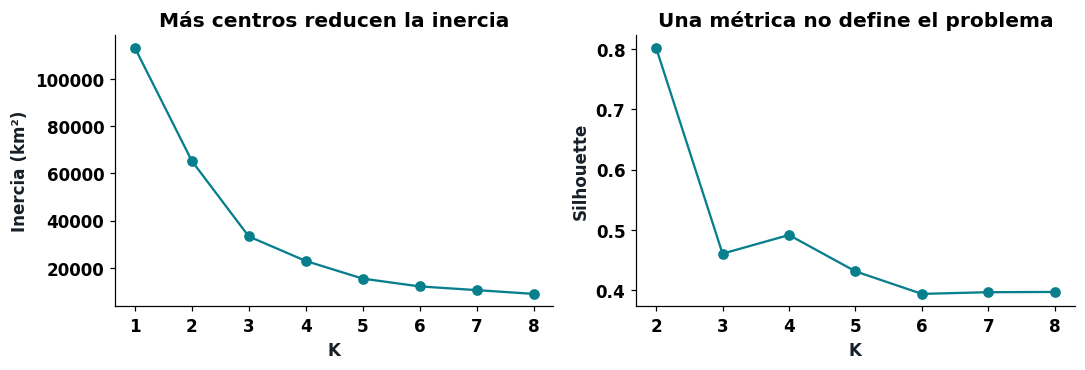

In [2]:
from sklearn.cluster import KMeans
toy=np.array([0.,1.,4.,5.])[:,None]
manual=KMeans(2,init=np.array([[0.],[4.]]),n_init=1,random_state=42).fit(toy)
print('Centros',manual.cluster_centers_.ravel(),'inercia',manual.inertia_)
assert np.isclose(manual.inertia_,1.)
rows=[]
for k in range(1,9):
    model=KMeans(k,n_init=10,random_state=42).fit(X)
    rows.append(dict(k=k,inertia=model.inertia_,silhouette=safe_silhouette(X,model.labels_)))
results=pd.DataFrame(rows); display(results); save_table(results,'kmeans_referencia')
fig,axes=plt.subplots(1,2,figsize=(10,3.5))
axes[0].plot(results.k,results.inertia,'o-'); axes[0].set(xlabel='K',ylabel='Inercia (km²)',title='Más centros reducen la inercia')
axes[1].plot(results.k,results.silhouette,'o-'); axes[1].set(xlabel='K',ylabel='Silhouette',title='Una métrica no define el problema')
fig.tight_layout(); savefig(fig,'14_kmeans')

## Conexión precisa con GMM
Con pesos iguales y covarianzas comunes $\sigma^2I$, maximizar la responsabilidad equivale a minimizar distancia
al centro. Cuando $\sigma^2\to0$, las responsabilidades se endurecen salvo empates. No significa que
un GMM general y K-means optimicen lo mismo.

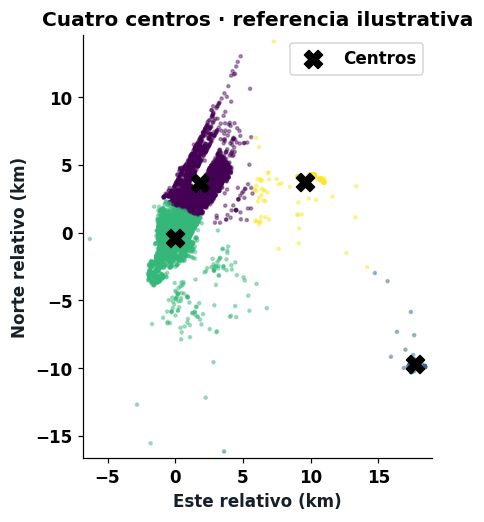

Inercia en cinco inicializaciones únicas:
[22920.851337569708, 22923.76321489932, 23403.22481807739, 22923.031362896334, 23402.919630885477]


In [3]:
fig,ax=plt.subplots(figsize=(7,5))
model=KMeans(4,n_init=10,random_state=42).fit(X)
ax.scatter(*X.T,c=model.labels_,cmap='viridis',s=4,alpha=.4)
ax.scatter(*model.cluster_centers_.T,marker='X',s=140,c='black',label='Centros')
spatial_axes(ax,X,'Cuatro centros · referencia ilustrativa'); ax.legend()
savefig(fig,'15_kmeans_espacial')
print('Inercia en cinco inicializaciones únicas:')
print([KMeans(4,n_init=1,random_state=s).fit(X).inertia_ for s in range(5)])

### Para resolver

¿Por qué los centros no son automáticamente ubicaciones para estaciones? ¿Qué aporta n_init?

**Mi respuesta y evidencia:**

_Escriba aquí su razonamiento; incluya unidades y una limitación._

## Fuentes y reproducción
- Microcurrículo y guía docente ML2, sesiones 19–24; adaptación del cuaderno histórico del profesor.
- [GMM](https://scikit-learn.org/stable/modules/mixture.html), [KDE](https://scikit-learn.org/stable/modules/density.html), [clustering](https://scikit-learn.org/stable/modules/clustering.html).
- Dataset suministrado por el docente; ver `datasets/semana-08/README.md` y `manifest.json`.
- Dependencias fijadas en `requirements-week8.txt`. Inicie el kernel en una carpeta del paquete.